# Set up a new ELP simulation

Plan, prepare, and launch a new surface-attached ELP simulation. Run the
cells in order:

1. **Plan geometry** — enter the sequence, surface concentration, and number
   of chains; get the box size, starting spacing, and a to-scale scatter plot
   so you can see overlap before generating any files.
2. **Prepare + submit to DelftBlue** — generates `simulations/<sim_name>/`
   targeting CUDA/SLURM and prints the `sbatch` command (does not submit
   automatically).
3. **Prepare + run locally (no sbatch/job.sh)** — generates a separate
   `simulations/<sim_name>-cpu/` or `-cuda/` and runs it directly, either as
   a quick CPU smoke test or, if a GPU is actually attached to this kernel
   (own workstation, or an interactive DelftBlue GPU allocation), straight
   on the GPU without ever going through `sbatch`.

simulation:      my-elp-sim_db
sequence:        30 residues
box:             [10.95, 10.95, 50.0] nm
anchor spacing:  3.161 nm

production run ('steps', used by the DelftBlue submit cell):
  requested steps: 7,070,000
  actual steps:    7,070,000
  simulated time:  70.700 ns
  save every:      7,000 steps (70.000 ps/frame)
  saved frames:    1,010  <- this is what len(u.trajectory) will be in the Analyze section

local smoke test ('local_steps', used by the local run cell):
  requested steps: 20,000
  actual steps:    20,000
  simulated time:  0.200 ns
  save every:      20 steps (0.200 ps/frame)
  saved frames:    1,000  <- this is what len(u.trajectory) will be in the Analyze section


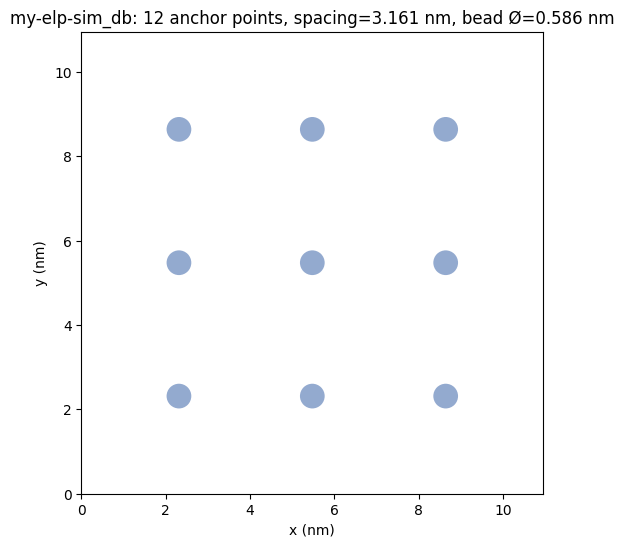

In [53]:
import csv

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle

from tools.elibpy import build_sequence_with_features, humanize_seq
from tools.new_simulation import (
    MIN_BOX_L,
    Z_HEIGHT,
    _validate_sequence,
    get_clockwise_position,
    plan_box,
    plan_steps,
)

# ---- Inputs --------------------------------------------------------------
sim_name = "my-elp-sim_db"                        # simulations/<sim_name>/ — reused by every cell below

USE_ELP_BUILDER = False  # True: build `sequence` from `components` below via tools.elibpy; False: use the raw string

# Used when USE_ELP_BUILDER = False. Residue 0 becomes the surface anchor ("Z").
sequence = "VPGVGVPGVGVPGVGVPGVGVPGVGVPGVG"     # single-letter AAs

# Used when USE_ELP_BUILDER = True — same (token, label) format as tools.elibpy.build_sequence_with_features:
#   "<letter><count>"  -> that many VPG<letter>G repeats, e.g. "V5" -> VPGVGVPGVGVPGVGVPGVGVPGVG
#   "(FRAGMENT)"        -> literal sequence fragment, inserted as-is
components = [
    ("V10", "VPGVG repeat"),
    ("K1", "lvpgkg"),
    ("I5", "VPGIG repeat"),
    ("V10", "VPGVG repeat"),
    ("K1", "lvpgkg"),
    ("I5", "VPGIG repeat"),
]

if USE_ELP_BUILDER:
    built = build_sequence_with_features(components)
    sequence = built["seq"]
    print(f"built sequence:  {humanize_seq(components)}")

concentration = 0.1                            # ELP chains / nm^2 (surface concentration)
nmol = 12                                       # number of ELP molecules

# Step counts — the single source of truth used by every cell below (DelftBlue submit
# and local run both read `steps`/`local_steps` from here instead of redefining them).
steps = 7_070_000        # total MD production steps, used by the DelftBlue/GPU submit cell
local_steps = 20_000      # smaller step count for the local CPU/GPU smoke-test cell

# Caps the save interval (steps between saved trajectory frames) that `plan_steps`
# below is allowed to pick — see the "steps -> frames" printout for what this
# actually produces. CALVADOS/create_simulation's own default is 7000; lower it if
# you want more temporal resolution (more saved frames) at a given step count.
max_n_save = 7000
# ---------------------------------------------------------------------------

seq = _validate_sequence(sequence)
plan = plan_box(len(seq), concentration, nmol)

# Per-residue bead diameter (sigma, nm) from the CALVADOS force field.
sigmas: dict[str, float] = {}
with open("residues_CALVADOS2.csv", newline="") as f:
    for row in csv.DictReader(f):
        sigmas[row["one"]] = float(row["sigmas"])
anchor_sigma = sigmas["Z"]  # bead sitting at each anchor point (residue 0 is tagged "Z")

print(f"simulation:      {sim_name}")
print(f"sequence:        {len(seq)} residues")
print(f"box:             [{plan.l_box}, {plan.l_box}, {Z_HEIGHT}] nm")
if plan.clamped:
    achieved = round(nmol / plan.l_box ** 2, 5)
    print(f"⚠  requested concentration would need a box below the {MIN_BOX_L} nm floor required by "
          f"CALVADOS's default cutoffs — box clamped to {plan.l_box} nm "
          f"(achieved concentration ≈ {achieved} chains/nm²)")
print(f"anchor spacing:  {plan.spacing} nm")
if plan.spacing_too_tight:
    print(f"⚠  spacing ({plan.spacing} nm) is tighter than a rough own-size estimate for a "
          f"{len(seq)}-residue chain ({plan.min_sane_spacing:.2f} nm) — chains will start heavily "
          f"overlapped and the simulation is likely to diverge to NaN. Lower the concentration and/or nmol.")
if plan.spacing < anchor_sigma:
    print(f"⚠  spacing ({plan.spacing} nm) is smaller than a single bead's own diameter "
          f"({anchor_sigma:.3f} nm) — even the anchor beads themselves will overlap.")

# ---- steps -> frames: exactly what create_simulation() will compute internally ----
# CALVADOS's Langevin integrator uses a fixed 0.01 ps (10 fs) timestep per step
# (see calvados/sim.py) — that's not configurable from here, only `steps` is.
DT_PS = 0.01

def _print_step_plan(label: str, n_steps: int) -> None:
    n_save, n_frames, actual_steps = plan_steps(n_steps, max_n_save=max_n_save)
    rounded_note = "" if actual_steps == n_steps else f"  (rounded from {n_steps:,})"
    print(f"\n{label}:")
    print(f"  requested steps: {n_steps:,}")
    print(f"  actual steps:    {actual_steps:,}{rounded_note}")
    print(f"  simulated time:  {actual_steps * DT_PS / 1000:.3f} ns")
    print(f"  save every:      {n_save:,} steps ({n_save * DT_PS:.3f} ps/frame)")
    print(f"  saved frames:    {n_frames:,}  <- this is what len(u.trajectory) will be in the Analyze section")

_print_step_plan("production run ('steps', used by the DelftBlue submit cell)", steps)
_print_step_plan("local smoke test ('local_steps', used by the local run cell)", local_steps)

# ---- 2D preview of the starting grid, anchor points sized to bead diameter ----
centers = np.array([get_clockwise_position(i)[:2] for i in range(nmol)], dtype=float)
centers = centers * plan.spacing + plan.l_box / 2

fig, ax = plt.subplots(figsize=(6, 6))
for x, y in centers:
    ax.add_patch(Circle((x, y), radius=anchor_sigma / 2, facecolor="#4c72b0", edgecolor="none", alpha=0.6))
ax.set_xlim(0, plan.l_box)
ax.set_ylim(0, plan.l_box)
ax.set_aspect("equal")
ax.set_xlabel("x (nm)")
ax.set_ylabel("y (nm)")
ax.set_title(f"{sim_name}: {nmol} anchor points, spacing={plan.spacing} nm, bead Ø={anchor_sigma:.3f} nm")
plt.show()

## Prepare + submit to DelftBlue (GPU/SLURM)

Uses `sequence`/`concentration`/`nmol`/`steps`/`max_n_save` from the setup
cell above (see its "steps -> frames" printout for exactly how many frames
this run will save). Generates `simulations/<sim_name>/` (config, FASTA,
`run.py`, `job.sh`) targeting CUDA on DelftBlue's GPU partition.
`SUBMIT_TO_DELFTBLUE` defaults to `False` so nothing is queued until you
explicitly opt in and rerun the cell.

In [54]:
from tools.new_simulation import create_simulation

partition = "gpu-a100"       # SLURM partition
walltime = "24:30:00"        # SLURM walltime (HH:MM:SS)
cpu_per_task = "18"          # SLURM --cpus-per-task

SUBMIT_TO_DELFTBLUE = False  # set True (and rerun) to actually `sbatch` the job

sim_dir = create_simulation(
    sequence=sequence,
    concentration=concentration,
    nmol=nmol,
    steps=steps,
    name=sim_name,
    platform="CUDA",
    partition=partition,
    walltime=walltime,
    cpu_per_task=cpu_per_task,
    max_n_save=max_n_save,
)

job_script = sim_dir / "runtime" / "job.sh"
print(f"\nruntime/ ready at {sim_dir / 'runtime'}")
print(f"To submit by hand (from a DelftBlue login node):\n  sbatch {job_script}")

if SUBMIT_TO_DELFTBLUE:
    import subprocess

    print(f"\n▶  Submitting to SLURM: {sim_name}")
    subprocess.run(["sbatch", str(job_script)], check=True)

TypeError: create_simulation() got an unexpected keyword argument 'max_n_save'

## Prepare + run locally (no sbatch/job.sh)

Uses `local_steps`/`max_n_save` from the setup cell above (see its "local
smoke test" printout for exactly how many frames this run will save).
Generates a separate `simulations/<sim_name>-<platform>/` (so it never
collides with the DelftBlue folder above) and runs it directly in this
notebook — no `sbatch`/`job.sh` involved either way. Set `platform` to
`"CPU"` for a quick sanity check, or `"CUDA"` to run on a GPU directly.

`"CUDA"` only works where a GPU is actually attached to whatever machine/
kernel this notebook is running on: your own workstation if it has an
NVIDIA GPU, or — on DelftBlue — a compute node you're already attached to
interactively (`srun --partition=gpu-a100 --gpus=1 --pty bash` from a login
node, then launch Jupyter from inside that shell). DelftBlue's login nodes
themselves have no GPU, so `platform="CUDA"` will fail there.

In [ ]:
import subprocess
import sys
from pathlib import Path

from openmm import Context, Platform, System, VerletIntegrator

from tools.new_simulation import _slugify, create_simulation

platform = "CPU"                 # "CPU" or "CUDA" — see markdown above for where "CUDA" actually works

# create_simulation() slugifies its `name` (e.g. "_" -> "-") when it picks the folder
# name — slugify here too so this cell checks/runs the exact same folder it created,
# even if `sim_name` itself contains characters that get normalized away.
local_sim_name = _slugify(f"{sim_name}-{platform.lower()}")

if platform == "CUDA":
    # Listing platform names isn't enough — OpenMM reports "CUDA" as compiled-in even
    # with no GPU attached (e.g. on a DelftBlue login node). Actually try to open a
    # device so this fails clearly here instead of deep inside create_simulation/run.py.
    try:
        _probe_system = System()
        _probe_system.addParticle(1.0)
        Context(_probe_system, VerletIntegrator(1.0), Platform.getPlatformByName("CUDA"))
    except Exception as e:
        raise RuntimeError(
            "Could not initialize a CUDA device on this kernel — no GPU is attached here "
            "(see the markdown cell above for how to get one on DelftBlue)."
        ) from e

local_sim_dir = Path("simulations") / local_sim_name
if local_sim_dir.exists():
    print(f"↻  simulations/{local_sim_name}/ already exists — reusing it "
          f"(delete the folder, or change sim_name/local_steps, to regenerate).")
else:
    local_sim_dir = create_simulation(
        sequence=sequence,
        concentration=concentration,
        nmol=nmol,
        steps=local_steps,
        name=local_sim_name,
        platform=platform,
        max_n_save=max_n_save,
    )

print(f"▶  Running locally on {platform}: {local_sim_dir.name}")
subprocess.run(
    [sys.executable, "-m", f"simulations.{local_sim_dir.name}.runtime.run"],
    check=True,
)

# Analyze results

The cells below load a finished trajectory (`sim_name` here is independent of
the setup section above — point it at whichever simulation you want to
inspect).

In [25]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt

sim_name = "derde"

path_top = f"simulations/{sim_name}/runtime/top.pdb"
path_tra = f"simulations/{sim_name}/runtime/{sim_name}.dcd"
u = mda.Universe(path_top, path_tra)

# Everything below is derived from the topology/trajectory themselves, so the
# rest of this notebook adapts to whatever PDB it's pointed at (chain count,
# chain length, box size, which end is anchored) instead of assuming the
# shape of one specific simulation.
chains = u.segments
n_chains = len(chains)

chain_lengths = {len(seg.residues) for seg in chains}
if len(chain_lengths) != 1:
    raise ValueError(f"Chains have differing lengths: {sorted(chain_lengths)}")
n_res_per_chain = chain_lengths.pop()

box = u.dimensions[:3].copy()  # [x, y, z] in Angstrom, read from the PDB's CRYST1 record

print(f"{n_chains} chains x {n_res_per_chain} residues/chain, box = {box}")

def get_pos_of_residue(chain_idx, res_idx):
    """CA position of residue `res_idx` (within-chain) of chain `chain_idx`, across all frames."""
    atom = chains[chain_idx].residues[res_idx].atoms.select_atoms("name CA")
    positions = np.empty((len(u.trajectory), 3))
    for i, ts in enumerate(u.trajectory):
        positions[i] = atom.positions[0]
    return positions

def track_atoms(atomgroup):
    """Positions of every atom in `atomgroup`, across all frames: shape (n_frames, n_atoms, 3)."""
    positions = np.empty((len(u.trajectory), len(atomgroup), 3))
    for i, ts in enumerate(u.trajectory):
        positions[i] = atomgroup.positions
    return positions

# Which chain end sits near the surface (small z) vs. dangles freely: found
# from the trajectory itself rather than assumed, so it stays correct whether
# the anchor tag was built onto residue 0 or residue -1 of the sequence.
probe_chains = range(0, n_chains, max(1, n_chains // 5))
empty = u.atoms[:0]
first_end = sum((chains[c].residues[0].atoms.select_atoms("name CA") for c in probe_chains), empty)
last_end = sum((chains[c].residues[-1].atoms.select_atoms("name CA") for c in probe_chains), empty)
mean_z_first = track_atoms(first_end)[..., 2].mean()
mean_z_last = track_atoms(last_end)[..., 2].mean()
anchor_idx, free_idx = (0, -1) if mean_z_first < mean_z_last else (-1, 0)

print(f"anchored end: residue index {anchor_idx} (mean z={min(mean_z_first, mean_z_last):.1f} Å); "
      f"free end: residue index {free_idx} (mean z={max(mean_z_first, mean_z_last):.1f} Å)")

40 chains x 10 residues/chain, box = [100. 100. 500.]
anchored end: residue index 0 (mean z=16.2 Å); free end: residue index -1 (mean z=23.2 Å)


## Amino acid distribution along z

Pick a single-letter amino acid code (`aa_letter`, matching the `one` column
of `residues_CALVADOS2.csv`) and see how that residue type is distributed
across the z-height, pooled over every chain and every saved frame from
`start_frame` onward (raise `start_frame` to drop early/equilibration
frames from the histogram).

In [ ]:
import csv

import numpy as np
import matplotlib.pyplot as plt

aa_letter = "V"    # single-letter amino acid code to inspect (see residues_CALVADOS2.csv "one" column)
start_frame = 0    # first saved frame to include (0-based) — raise this to skip equilibration frames

# one-letter -> three-letter resname, from the same CALVADOS residue table used to build the topology
one_to_three = {}
with open("residues_CALVADOS2.csv", newline="") as f:
    for row in csv.DictReader(f):
        one_to_three[row["one"]] = row["three"]
if aa_letter not in one_to_three:
    raise ValueError(f"Unknown amino acid letter {aa_letter!r} — see residues_CALVADOS2.csv")
target_resname = one_to_three[aa_letter]

# The surface anchor (residue anchor_idx of every chain) is always relabelled "Z" in the
# topology regardless of the original sequence letter, and "Z" reuses valine's
# resname/sigma — exclude those beads so a query for "V" isn't contaminated by the
# (wall-constrained) anchors.
anchor_ca = sum(
    (chains[c].residues[anchor_idx].atoms.select_atoms("name CA") for c in range(n_chains)),
    empty,
)
target_ca = u.select_atoms(f"name CA and resname {target_resname}") - anchor_ca

if len(target_ca) == 0:
    # sim_name here is independent of any sequence built earlier in the notebook —
    # this trajectory simply may never have contained an '{aa_letter}'. Show what it
    # actually does contain so that's obvious instead of a guessing game.
    present = sorted({res.resname for res in chains[0].residues})
    raise ValueError(
        f"No non-anchor '{aa_letter}' ({target_resname}) residues found in trajectory "
        f"'{sim_name}'. Residue types actually present in this trajectory: {present}. "
        f"(sim_name in this Analyze section is independent of any sequence set up above — "
        f"make sure you prepared/ran a simulation whose sequence contains '{aa_letter}', "
        f"then point sim_name at that simulation's folder.)"
    )

if not (0 <= start_frame < len(u.trajectory)):
    raise ValueError(f"start_frame={start_frame} is out of range for {len(u.trajectory)} frames.")

z_all_full = track_atoms(target_ca)[..., 2]  # shape (n_frames, n_target_atoms), every saved frame
z_all = z_all_full[start_frame:]             # frames >= start_frame; also used by the cumulative-average cell below
anchor_z = min(mean_z_first, mean_z_last)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(z_all.ravel(), bins=60, density=True, color="#4c72b0", alpha=0.8)
ax.axvline(anchor_z, color="black", linestyle="--", linewidth=1, label="anchor z")
ax.set_xlabel("z (Å)")
ax.set_ylabel("probability density")
ax.set_title(f"{sim_name}: z-distribution of '{aa_letter}' ({target_resname}), "
             f"{target_ca.n_atoms} residues x {z_all.shape[0]}/{z_all_full.shape[0]} frames "
             f"(from frame {start_frame})")
ax.legend()
plt.show()


## Cumulative average distribution over time (equilibration check)

Uses `z_all` from the cell above (i.e. already restricted to frames >=
`start_frame` — frame indices below are relative to that offset). Shows the
z-distribution of `aa_letter` built from only the first `t` frames, for
growing `t`, plus how far that cumulative-average distribution still is from
the full-trajectory one (total-variation distance). Once the distance
settles near zero, adding more frames no longer changes the distribution —
i.e. the simulation has become stable for this residue.

In [ ]:
n_frames_total, n_target_atoms = z_all.shape

n_bins = 60
bins = np.linspace(0, box[2], n_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_width = bins[1] - bins[0]

# Per-frame counts, then cumulative over frames -> a density profile built from
# only frames [0, t] for every t, each normalized to integrate to 1 on its own.
per_frame_counts = np.array(
    [np.histogram(z_all[t], bins=bins)[0] for t in range(n_frames_total)], dtype=float
)
cum_counts = np.cumsum(per_frame_counts, axis=0)
cum_density = cum_counts / (cum_counts.sum(axis=1, keepdims=True) * bin_width)
final_density = cum_density[-1]  # profile from the whole trajectory

# Total-variation distance between the cumulative profile up to frame t and the
# full-trajectory profile: how much the "average so far" still has left to move.
drift = np.abs(cum_density - final_density).sum(axis=1) * bin_width

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
checkpoints = np.unique(np.linspace(0, n_frames_total - 1, min(8, n_frames_total), dtype=int))
cmap = plt.get_cmap("viridis")
for i, t in enumerate(checkpoints):
    ax.plot(bin_centers, cum_density[t], color=cmap(i / max(1, len(checkpoints) - 1)),
            label=f"frames 0-{t + 1}")
ax.set_xlabel("z (\u00c5)")
ax.set_ylabel("cumulative probability density")
ax.set_title(f"'{aa_letter}' z-distribution, cumulative average over time")
ax.legend(fontsize=7, ncol=2)

ax = axes[1]
ax.plot(np.arange(1, n_frames_total + 1), drift, color="#c44e52")
ax.set_xlabel("frame index")
ax.set_ylabel("TV distance to full-trajectory profile")
ax.set_title("convergence of the cumulative distribution")

# Heuristic "stable after" point: the first frame beyond which drift never
# exceeds `tol` again (tail-anchored, so an early lucky dip isn't flagged).
tol = 0.05
above_tol = np.nonzero(drift > tol)[0]  # 0-indexed frames still above tolerance
if above_tol.size == 0:
    stable_frame = 1
elif above_tol[-1] == n_frames_total - 1:
    stable_frame = None
else:
    stable_frame = above_tol[-1] + 2  # 1-indexed frame right after the last violation

if stable_frame is not None:
    ax.axvline(stable_frame, color="black", linestyle="--", linewidth=1)
    ax.text(stable_frame, drift.max(), f" stable from frame {stable_frame}", va="top")
    print(f"'{aa_letter}' z-distribution looks stable (TV distance <= {tol}) from frame "
          f"{stable_frame}/{n_frames_total} onward.")
else:
    print(f"'{aa_letter}' z-distribution never settles within TV distance {tol} of the "
          f"full-trajectory profile \u2014 try a looser tol, more sampling, or check for a slow drift.")

fig.tight_layout()
plt.show()


## Free-end 3D trajectories

The path traced by the free end (residue index `free_idx` — the end
*opposite* the surface anchor) of a sample of `max_chains_3d` chains, across
every saved frame — one colored line per chain. Axes are box coordinates in
Å, scaled to the actual simulation box (`box[0] x box[1] x box[2]`) so you
can see how much of the box each chain's free end actually explores, and
whether that exploration stays close to the surface (small z, near the
dashed anchor level used in later cells) or wanders throughout the box.

In [ ]:
fig = plt.figure()
ax = plt.axes(projection='3d')

max_chains_3d = 15
sample_chain_idx = np.linspace(0, n_chains - 1, min(max_chains_3d, n_chains), dtype=int)

trajectories = []
for c in sample_chain_idx:
    positions = get_pos_of_residue(c, free_idx)
    trajectories.append(positions)

    ax.plot3D(positions[:, 0], positions[:, 1], positions[:, 2], alpha=.5)

ax.axes.set_xlim3d([0, box[0]])
ax.axes.set_ylim3d([0, box[1]])
ax.axes.set_zlim3d([0, box[2]])
ax.set_xlabel("x (Å)")
ax.set_ylabel("y (Å)")
ax.set_zlabel("z (Å)")
ax.set_title(f"{sim_name}: free-end (residue {free_idx}) trajectory of {len(sample_chain_idx)}/{n_chains} chains")
plt.show()

## Free-end x/y/z coordinates over time, per chain

Same sample of chains as the 3D plot above, but split into individual x, y,
and z coordinate traces (rows) against frame number (columns = chains), so
you can read off each axis separately instead of untangling a 3D plot. The
dashed line on the z row is `anchor_z` — the mean z of the anchored end
(from the "load trajectory" cell) — so you can see at a glance how far each
chain's free end sits above the surface, and whether it drifts, oscillates,
or has settled into a steady range over the run. This renders once from the
already-loaded trajectory (not a live view), so it does not need to keep
running after it draws.

In [ ]:
max_chains_grid = 10
grid_chain_idx = np.linspace(0, n_chains - 1, min(max_chains_grid, n_chains), dtype=int)
n_cols = len(grid_chain_idx)

anchor_z = min(mean_z_first, mean_z_last)  # reference line: mean z of the anchored end
axis_labels = ["x (Å)", "y (Å)", "z (Å)"]
colors = ["red", "green", "blue"]

fig, axs = plt.subplots(3, n_cols, figsize=(3 * n_cols, 6), squeeze=False, sharex=True)

for i, c in enumerate(grid_chain_idx):
    positions = get_pos_of_residue(c, free_idx)
    axs[0, i].set_title(f"chain {chains[c].segid}")

    for j in range(3):
        axs[j, i].plot(positions[:, j], color=colors[j])
        axs[j, i].grid()
        if i == 0:
            axs[j, i].set_ylabel(axis_labels[j])
        if j == 2:
            axs[j, i].set_xlabel("frame index")

    axs[2, i].axhline(anchor_z, color="black", linestyle="--", linewidth=1,
                       label="anchor z (mean)" if i == 0 else None)

axs[2, 0].legend(fontsize=7, loc="upper right")
fig.suptitle(f"{sim_name}: free-end (residue {free_idx}) x/y/z coordinates over time, "
             f"{n_cols}/{n_chains} chains")
fig.tight_layout()
plt.show()